### 2.2.2 核岭回归

我们不必采用多项式基函数，而是可以参照 2.1.2 节的方式使用径向基函数来逼近隐含函数，由此便可推导出核岭回归。核函数 $K(\cdot,\cdot)$ 并不要求具备径向特性，但必须满足对称性与正定性，也就是 $K(\boldsymbol{u},\boldsymbol{v}) = K(\boldsymbol{v},\boldsymbol{u})$，且符合定义 2.1。本书主要采用平移不变核 $K(\boldsymbol{u},\boldsymbol{v})=R(\boldsymbol{u}-\boldsymbol{v})$，不过仍会针对通用类型的核函数介绍核岭回归。设含噪声数据集为 $\{(\boldsymbol{x}_i, y_i)\}_{i=1}^n$，我们需要拟合模型：

$$
y_i=\sum_{j=1}^n c_jK(\boldsymbol{x}_i, \boldsymbol{x}_j) + \epsilon_i
$$

其中 $\epsilon_i$ 独立同分布，服从正态分布 $\epsilon_i\stackrel{\text{iid}}{\sim}N(0, \sigma^2)$，且假定 $y_i$ 已经中心化处理。由此可构建最小二乘优化目标：

$$
\min_{\boldsymbol{c}} (\boldsymbol{y}-\boldsymbol{K}\boldsymbol{c})'(\boldsymbol{y}-\boldsymbol{K}\boldsymbol{c})
$$

式中 $\boldsymbol{K}$ 为 $n$ 阶方阵，其第 $i$ 行第 $j$ 列元素为 $K(\boldsymbol{x}_i, \boldsymbol{x}_j)$，$\boldsymbol{c} = (c_1, \dots, c_n)'$。但正如 2.1.2 节所述，只要所有 $\boldsymbol{x}_i$ 互不相同，该优化问题存在唯一解 $\hat{\boldsymbol{c}} = \boldsymbol{K}^{-1}\boldsymbol{y}$。此时得到的预测器本质是插值器，对于含噪声数据而言这通常并非理想结果：预测结果会产生不必要的剧烈波动，难以精准逼近真实的隐含函数。我们可通过正则化手段解决该问题，即在最小二乘目标函数中增加惩罚项，以此约束预测器的波动幅度。令预测函数 $h_n(\boldsymbol{x}) = \boldsymbol{k}(\boldsymbol{x})'\boldsymbol{c}$，$\boldsymbol{k}(\boldsymbol{x})$ 是 $n$ 维列向量，其第 $i$ 个元素为 $K(\boldsymbol{x}, \boldsymbol{x}_i)$。最终需求解的优化问题为：

$$
\min_{\boldsymbol{c}} (\boldsymbol{y}-\boldsymbol{K}\boldsymbol{c})'(\boldsymbol{y}-\boldsymbol{K}\boldsymbol{c}) + \lambda\|h_n\|^2
$$

式中 $\lambda > 0$，$\|h_n\|$ 为函数 $h_n(\cdot)$ 的范数，用于控制函数的波动程度。

要为函数 $h_n(\cdot)$ 定义合适的范数，首先需要划定一个函数类，并将 $h_n(\cdot)$ 归入该函数类中。考察由核函数线性张成构成的函数类：

$$
h(\cdot)=\sum_{i=1}^m \alpha_i K(\cdot, \boldsymbol{u}_i)
$$

式中 $m$ 可取任意正整数，$u_i$ 为定义域 $\mathcal{X}$ 内的任意点。针对该函数类中任意两个元素，其内积定义如下。设有两个函数

$$
f(\cdot)=\sum_{i=1}^m \alpha_i K(\cdot, \boldsymbol{u}_i),\quad g(\cdot)=\sum_{i=1}^n \beta_i K(\cdot, \boldsymbol{v}_i)
$$

则二者的内积定义为：

$$
\langle f, g\rangle=\sum_{i=1}^m\sum_{j=1}^n \alpha_i\beta_j K(\boldsymbol{u}_i, \boldsymbol{v}_j)
$$

由该内积诱导出的函数范数为 $\|f\|=\sqrt{\langle f, f\rangle}$。若将前文定义的函数类依照该范数取闭包，便可得到函数希尔伯特空间 $\mathcal{H}$。该空间具备再生性质 $\langle K(\cdot, \boldsymbol{u}), K(\cdot, \boldsymbol{v})\rangle=K(\boldsymbol{u}, \boldsymbol{v})$，因此被称作再生核希尔伯特空间（RKHS）。关于再生核希尔伯特空间的详细内容可参阅法斯豪尔与麦考特于 2015 年著作的第 2 章。

因此，预测函数 $h_n(\cdot) = \sum_{i=1}^n c_iK(\cdot, \boldsymbol{x}_i)$ 在核函数 $K(\cdot,\cdot)$ 对应的再生核希尔伯特空间下的范数满足：

$$
\|h_n\|^2 = \langle h_n, h_n\rangle=\sum_{i=1}^n\sum_{j=1}^n c_ic_jK(\boldsymbol{x}_i, \boldsymbol{x}_j) = \boldsymbol{c}'\boldsymbol{K}\boldsymbol{c}
$$

于是我们的优化问题写作：

$$
\min_{\boldsymbol{c}}\ (\boldsymbol{y}-\boldsymbol{K}\boldsymbol{c})'(\boldsymbol{y}-\boldsymbol{K}\boldsymbol{c}) + \lambda\boldsymbol{c}'\boldsymbol{K}\boldsymbol{c}
\tag{2.41}
$$

事实上，依据表示定理（瓦巴，1990）可以证明，该优化问题等价于下述无限维优化问题：

$$
\min_{h_n\in \mathcal{H}}\sum_{i=1}^n \big\{y_i - h_n(\boldsymbol{x}_i)\big\}^2 + \lambda\|h_n\|^2
$$

该优化形式看似难以求解，但式 (2.41) 的求解过程十分简便。将目标函数对 $\boldsymbol{c}$ 求导并令导数等于零，可得：

$$
-2\boldsymbol{K}(\boldsymbol{y}-\boldsymbol{K}\boldsymbol{c}) + 2\lambda\boldsymbol{K}\boldsymbol{c} = \boldsymbol{0}
$$

解得：

$$
\hat{\boldsymbol{c}} = (\boldsymbol{K}+\lambda\boldsymbol{I})^{-1}\boldsymbol{y}
\tag{2.42}
$$

将该结果与式 (2.40) 的岭回归解对比，便可理解该方法被命名为核岭回归的原因。接下来验证式 (2.40) 是其特例：设核函数 $K(u,v) = \boldsymbol{r}(u)'\boldsymbol{r}(v)$，其中 $\boldsymbol{r}(u) = (u,u^2,\dots,u^m)'$，此时 $\boldsymbol{K}=\boldsymbol{R}\boldsymbol{R}'$，$\boldsymbol{R}$ 为 $n\times m$ 矩阵，其第 $i$ 行是 $\boldsymbol{r}(x_i)'$。代入式 (2.41) 后优化问题变为：

$$
\min_{\boldsymbol{c}}\ (\boldsymbol{y}-\boldsymbol{R}\boldsymbol{R}'\boldsymbol{c})'(\boldsymbol{y}-\boldsymbol{R}\boldsymbol{R}'\boldsymbol{c}) + \lambda\boldsymbol{c}'\boldsymbol{R}\boldsymbol{R}'\boldsymbol{c}
$$

令 $\boldsymbol{\beta}=\boldsymbol{R}'\boldsymbol{c}$，上式即可化简为式 (2.39)。

核岭回归预测值 $\hat{y}(x) = \boldsymbol{k}(x)'\hat{\boldsymbol{c}}$ 必须在确定正则化参数 $\lambda$ 以及核函数内的参数 $\theta$ 之后才可使用。对此，我们仍可采用 2.1.2 节中的交叉验证方法。结合引理 2.5 能够求得留一交叉验证误差：

$$
cv_i = \frac{y_i - \boldsymbol{H}_i\boldsymbol{y}}{1 - \boldsymbol{H}_{ii}}
$$

其中 $\boldsymbol{H} = \boldsymbol{K}(\boldsymbol{K} + \lambda\boldsymbol{I})^{-1}$。该公式在 $\lambda=0$ 时无法直接使用，不过我们可对公式做化简以适配该情形。利用矩阵恒等式：

$$
\boldsymbol{I} - \boldsymbol{K}(\boldsymbol{K} + \lambda\boldsymbol{I})^{-1} = \lambda(\boldsymbol{K} + \lambda\boldsymbol{I})^{-1}
$$

推导可得：

$$
\begin{align*}
cv_i &= \frac{\left[\boldsymbol{y}-\left\{\boldsymbol{I}-\lambda(\boldsymbol{K}+\lambda\boldsymbol{I})^{-1}\right\}\boldsymbol{y}\right]_i}{\left(\boldsymbol{I}-\left\{\boldsymbol{I}-\lambda(\boldsymbol{K}+\lambda\boldsymbol{I})^{-1}\right\}\right)_{ii}}\\
&= \frac{\left[(\boldsymbol{K}+\lambda\boldsymbol{I})^{-1}\boldsymbol{y}\right]_i}{\left((\boldsymbol{K}+\lambda\boldsymbol{I})^{-1}\right)_{ii}}
\end{align*}
$$

当 $\lambda=0$ 时，该式与前文推导得到的式 (2.9) 完全一致。

再次回顾上一节用到的数据 $\{(x_i, y_i)\}_{i=1}^{20}$，该数据由式 (2.1) 中的一元函数生成。选取高斯核函数 $K(u, v) = \exp\left\{-(u-v)^2/\theta^2\right\}$。分别采用多折交叉验证（MSCV）与广义交叉验证（GCV）最小化准则估计参数 $\lambda$ 和 $\theta$，两种方法得到的结果一致：等间隔设计点下，参数估计值 $\hat{\lambda}=0.034$、$\hat{\theta}=0.082$；针对九次多项式的 D 最优设计点下，参数估计值 $\hat{\lambda}=0.034$、$\hat{\theta}=0.082$。对应的预测结果绘制于图 2.8 中，其预测效果远优于图 2.6、图 2.7 所示的多项式回归结果。

> **图 2.8** 采用 10 个等间隔设计点（左侧）与 D 最优设计点（右侧）、各设置两组重复试验的核岭回归。

MSCV: 
 theta: 0.08229282 
 lambda: 0.0342453 
GCV: 
 theta: 0.08263664 
 lambda: 0.03423414 


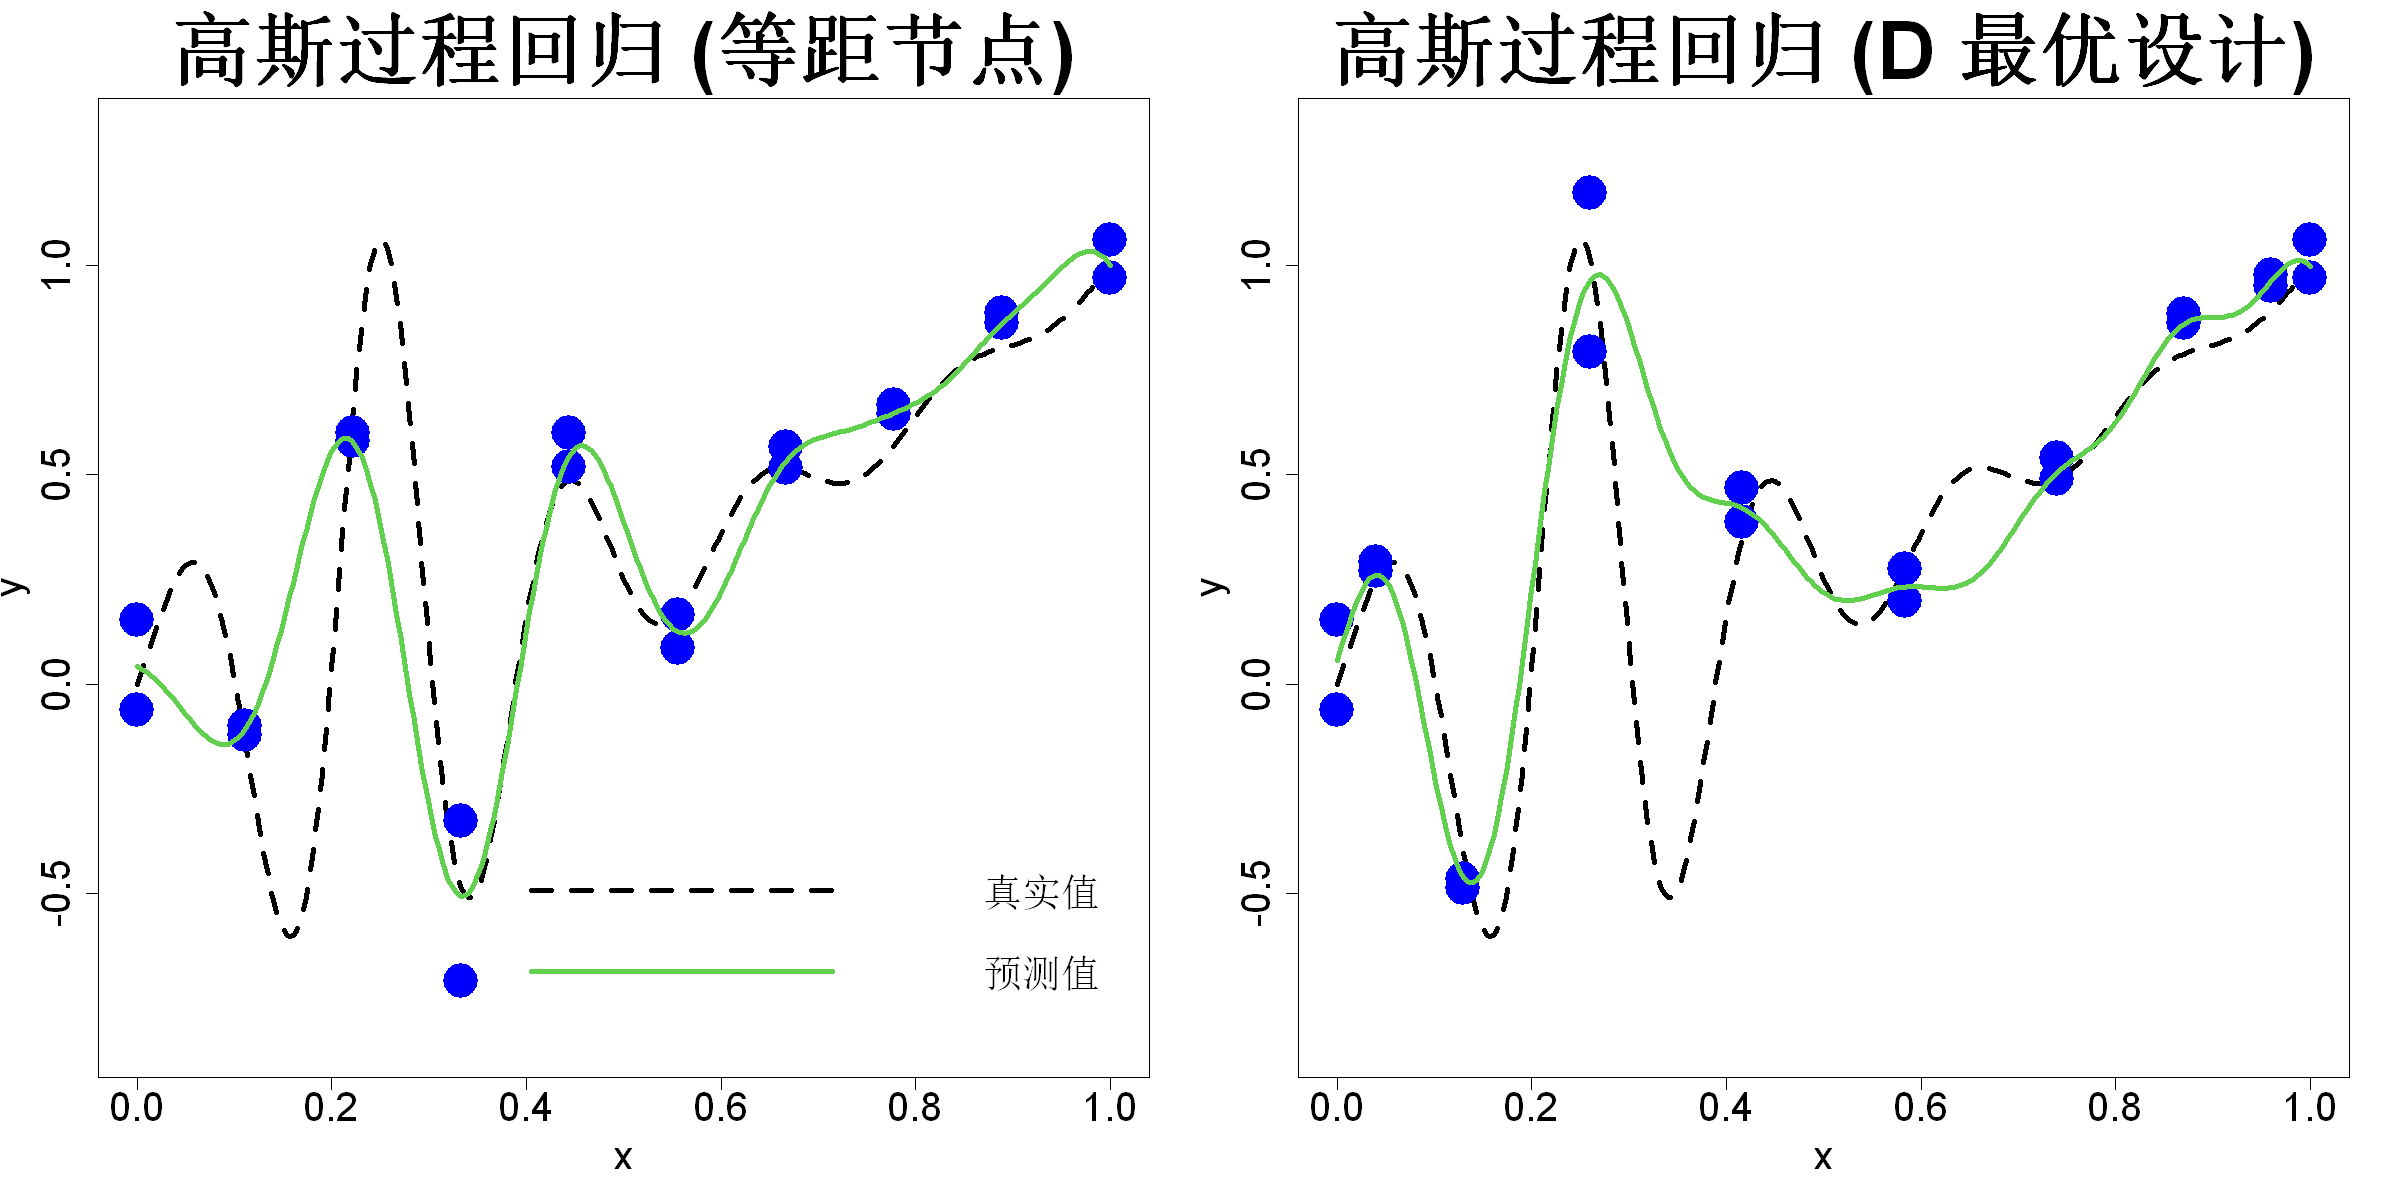

In [7]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
r=2
D=((1:n)-1)/(n-1)
D=rep(D,r)
set.seed(1)
e=rnorm(n*r,sd=.1)
y=f(D)+e

kernel=function(x,y,theta)exp(-(outer(x,y,"-")/theta)^2)
MSCV=function(para){
  theta=para[1]
  lam=para[2]
  R=kernel(D,D,theta)
  Rinv=solve(R+lam*diag(n*r))
  cv=c(Rinv%*%y)/diag(Rinv)
  mean(cv^2)
}
a=optim(c(.1,.1),MSCV,lower=c(.05,.001),upper=c(1,1),method="L-BFGS-B")
theta=a$par[1]
lam=a$par[2]
cat("MSCV:","\n","theta:",theta,"\n","lambda:",lam,"\n")

GCV=function(para){
  theta=para[1]
  lam=para[2]
  R=kernel(D,D,theta)
  Rinv=solve(R+lam*diag(n*r))
  cv=c(Rinv%*%y)/mean(diag(Rinv))
  mean(cv^2)
}
a=optim(c(.1,.1),GCV,lower=c(.05,.001),upper=c(1,1),method="L-BFGS-B")
theta=a$par[1]
lam=a$par[2]
cat("GCV:","\n","theta:",theta,"\n","lambda:",lam,"\n")

R=kernel(D,D,theta)
coef=solve(R+lam*diag(n*r),y)
R_pred=kernel(test,D,theta)
pred=as.vector(R_pred%*%coef)
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="高斯过程回归 (等距节点)",cex.main=4)
points(D,y,pch=16,cex=4,col="blue")
lines(test,pred,col=3,lwd=4)
legend(.25,-.3,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(4,4),bty="n",cex=2)

tests=2*test-1
cand_df=data.frame(x=tests)
library(AlgDesign)
a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand_df,approximate=FALSE)
D=rep(c(a$design[,1]),r)
D=((D+1)/2)
y=f(D)+e
R=kernel(D,D,theta)
coef=solve(R+lam*diag(n*r),y)
R_pred=kernel(test,D,theta)
pred=as.vector(R_pred%*%coef)
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="高斯过程回归 (D 最优设计)",cex.main=4)
points(D,y,pch=16,cex=4,col="blue")
lines(test,pred,col=3,lwd=4)
par(mfrow=c(1,1))